### Viktoria Ivanova - 7MI3400799

### Selling prices of villas in Landvetter

In this task, a linear regression model is build to check the relation between living areas and selling prices in Landvetter. Data will be processed in the best way for the needs of the tasks, in order to retrieve the most valuable information.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

Loading the data:

In [3]:
living_prices_df = pd.read_csv("data_assignment2.csv")
living_prices_df

,ID,Living_area,Rooms,Land_size,Biarea,Age,Selling_price
0,1,104,5.0,271.0,25.0,33,4600000
1,2,99,5.0,1506.0,6.0,88,4450000
2,3,133,6.0,486.0,NaN,44,4900000
3,4,175,7.0,728.0,NaN,14,6625000
4,5,118,6.0,1506.0,NaN,29,4600000
5,6,133,6.0,823.0,NaN,12,6650000
6,7,70,4.0,1685.0,70.0,53,2800000
7,8,134,6.0,1593.0,49.0,57,6100000
8,9,70,5.0,1120.0,102.0,81,3000000
9,10,133,6.0,1503.0,NaN,51,3000000


We can see relatively small amount of data, it cannot be sufficient for totally clear predictions and conclusions but a model can be created, based on the records.

In [4]:
living_prices_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,56.0,2.850000e+01,1.630951e+01,1.0,14.75,28.5,42.25,56.0
Living_area,56.0,1.286786e+02,3.600662e+01,63.0,104.00,133.0,154.25,210.0
Rooms,54.0,5.296296e+00,1.126518e+00,2.0,5.00,5.0,6.00,7.0
Land_size,55.0,1.125455e+03,6.566852e+02,218.0,526.50,1213.0,1615.00,3285.0
Biarea,32.0,3.909375e+01,3.167003e+01,6.0,18.25,30.0,52.50,118.0
Age,56.0,4.076786e+01,2.807910e+01,0.0,12.75,43.0,59.75,96.0
Selling_price,56.0,4.713125e+06,1.241117e+06,1775000.0,4075000.00,4812500.0,5831250.00,6800000.0


Let's see the ammount of missing data:

In [5]:
missing_values = living_prices_df.isna().mean().sort_values(ascending=False)
missing_values

Biarea           0.428571
Rooms            0.035714
Land_size        0.017857
ID               0.000000
Living_area      0.000000
Age              0.000000
Selling_price    0.000000
dtype: float64

Based on the result, we are going to check the dependency between the Living are and Selling price features, so we don't need to drop or fill the rows with their mean values.

Is is important to check for extremal values which can alter significantly the results and wrong assumptions might be made.

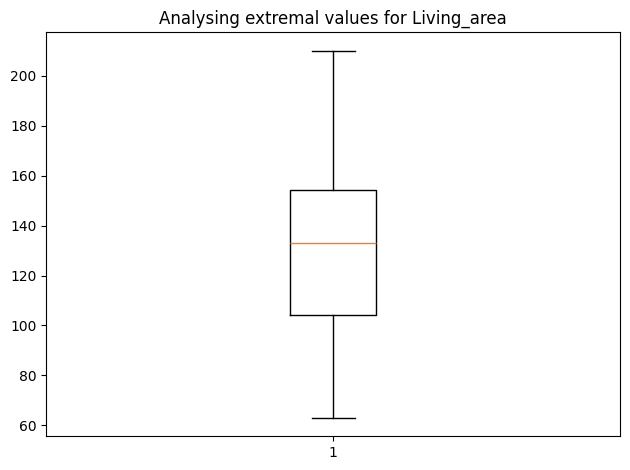

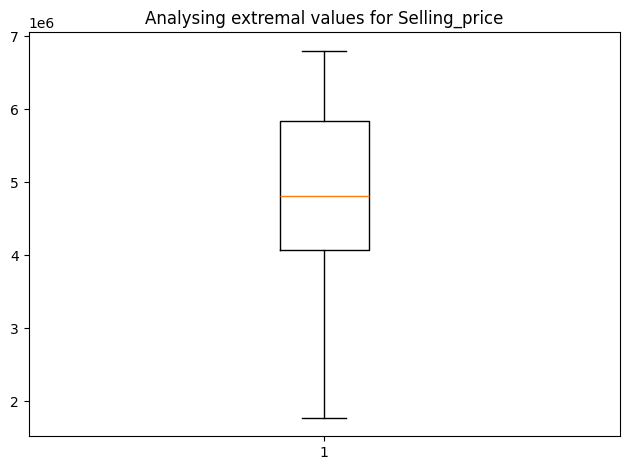

In [6]:
extremal_values_check = living_prices_df[['Living_area', 'Selling_price']]

for label, data in extremal_values_check.items():
    plt.title(f'Analysing extremal values for {label}')
    plt.boxplot(data)
    plt.tight_layout()
    plt.show()

In [7]:
living_prices_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             56 non-null     int64  
 1   Living_area    56 non-null     int64  
 2   Rooms          54 non-null     float64
 3   Land_size      55 non-null     float64
 4   Biarea         32 non-null     float64
 5   Age            56 non-null     int64  
 6   Selling_price  56 non-null     int64  
dtypes: float64(3), int64(4)
memory usage: 3.2 KB


Let's create a Linear regression model.

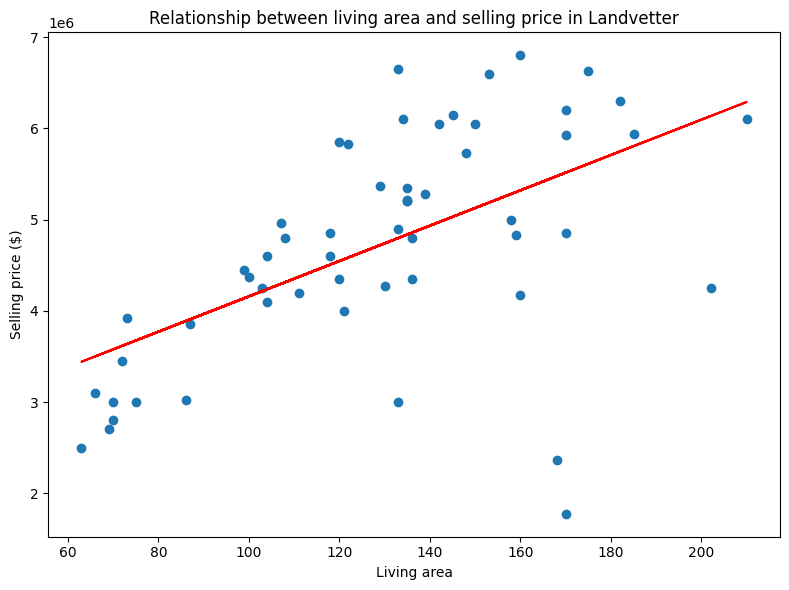

In [8]:
lin_regression = LinearRegression()
X_living_area = living_prices_df[['Living_area']]
y_selling_prices = living_prices_df[['Selling_price']]
lin_regression.fit(X_living_area, y_selling_prices)
predictions = lin_regression.predict(X_living_area)

plt.figure(figsize=(8, 6))
plt.scatter(X_living_area, y_selling_prices)
plt.title('Relationship between living area and selling price in Landvetter')
plt.plot(X_living_area, predictions, 'r')
plt.xlabel('Living area')
plt.ylabel('Selling price ($)')
plt.tight_layout()
plt.show()

In [9]:
r2 = lin_regression.score(X_living_area, y_selling_prices)
r2

0.31579478122912397

The R^2 score is pretty bad, however, with more data, better results can be received.

b. What are the values of the slope and intercept of the regression line?

In [15]:
print("Slope value: ", lin_regression.coef_[0])
print("Intercept: ", lin_regression.intercept_) 

Slope value:  [19370.13854733]
Intercept:  [2220603.24335587]


c. Use this model to predict the selling prices of houses which have living area
100 m2, 150 m2 and 200 m2.

In [ ]:
areas = [100, 150, 200]

areas_df = pd.DataFrame(areas, columns=['Living_area'])

area_predictions = lin_regression.predict(areas_df)
print(area_predictions)

d. Draw a residual plot.

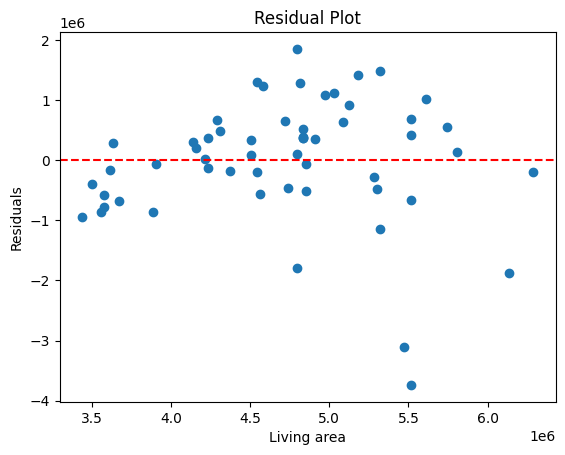

In [13]:
residuals = y_selling_prices - predictions


plt.scatter(predictions, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Living area')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

A lot of spreads are visual in the residual plot, so we can conclude that there is a dependency between the living area and the selling prices in Landvetter, but more records should be collected to be able to create a good investigation with valuable results.

### Iris dataset classification

In this project, we will investigate and process the iris dataset, included in sklearn.datasets, in order to be able to give answers to some ongoing questions about its classification and scores.

### Imports


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [ ]:
iris_dataset = load_iris()

X = iris_dataset.data
y = iris_dataset.target
target_names = iris_dataset.target_names
target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

a. Use a confusion matrix to evaluate the use of logistic regression to classify the
iris data set

0.9473684210526315


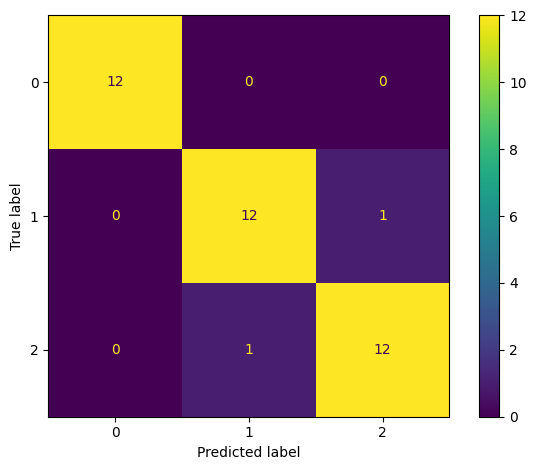

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

logistic_regression = LogisticRegression(random_state=42, max_iter=300)
logistic_regression.fit(X_train , y_train)
y_pred = logistic_regression.predict(X_test)
print(accuracy_score(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred, target_names=target_names))

We can conclude that the setosa is predicted correctly, virginica has 3 missclassified and versicolor has 1 missclassified

b. Use k-nearest neighbours to classify the iris data set with some different
values for k, and with uniform and distance-based weights. What will happen
when k grows larger for the different cases? Why?

KNN for k = 1


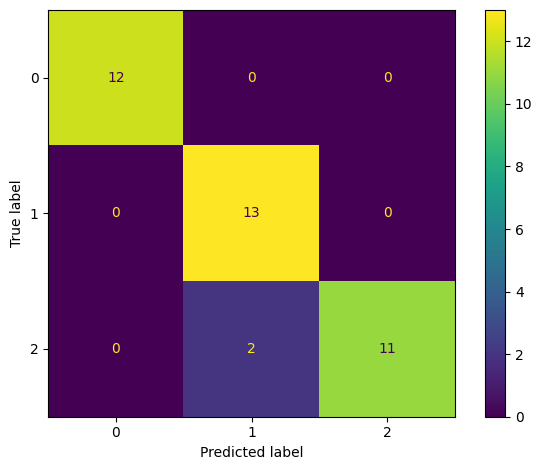

0.9473684210526315
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.87      1.00      0.93        13
   virginica       1.00      0.85      0.92        13

    accuracy                           0.95        38
   macro avg       0.96      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38

KNN for k = 3


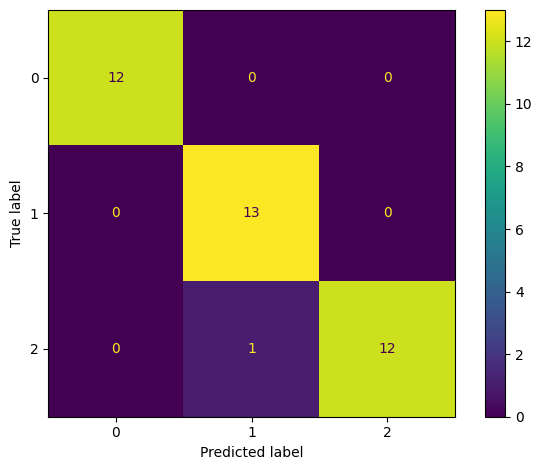

0.9736842105263158
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.93      1.00      0.96        13
   virginica       1.00      0.92      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38

KNN for k = 7


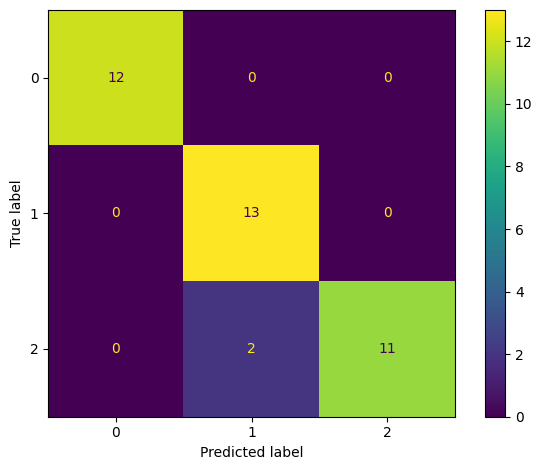

0.9473684210526315
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.87      1.00      0.93        13
   virginica       1.00      0.85      0.92        13

    accuracy                           0.95        38
   macro avg       0.96      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38

KNN for k = 9


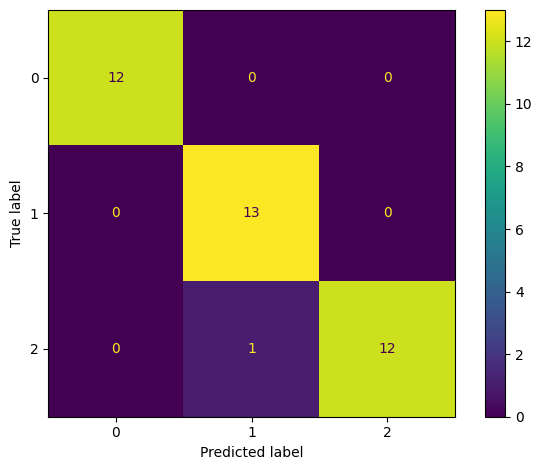

0.9736842105263158
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.93      1.00      0.96        13
   virginica       1.00      0.92      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38

KNN for k = 13


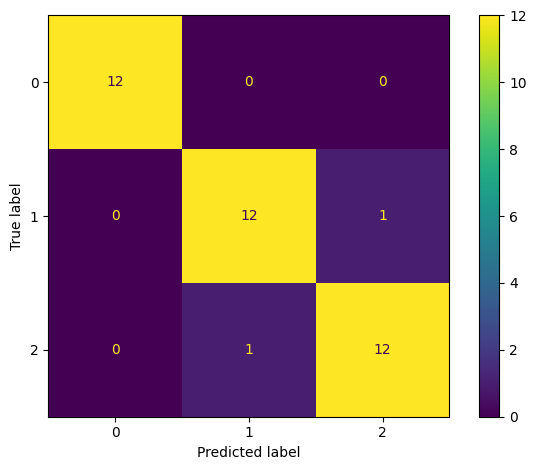

0.9473684210526315
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38

KNN for k = 21


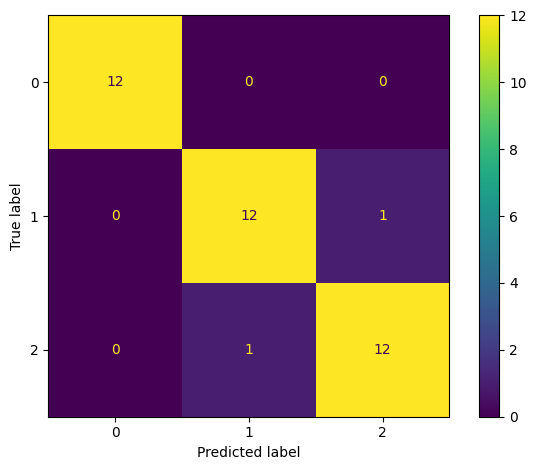

0.9473684210526315
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



In [ ]:
knn_values = [1, 3, 7, 9, 13, 21]

for k in knn_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred_knn = knn.predict(X_test)
    print("KNN for k =", k,)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
    plt.tight_layout()
    plt.show()

    print(accuracy_score(y_test, y_pred_knn))
    print(classification_report(y_test, y_pred_knn, target_names=target_names))

The best result is for k = 9, this is based on the result score and the visible confusion matrices. Larger k values cause over smoothing and lower accuracy.

In conclusion, Both Logistic regression and KNN result in high scores which means that the models are predicting very well.
The only problem with KNN is that for too large k, it causes loss of detail and worse performance.